In [78]:
#@title Imports & Utils

import pandas as pd
import ast
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [79]:
distmult_predictions = pd.read_csv("/content/DistMult_predictions.csv", index_col=False, sep="\t").dropna().drop_duplicates().reset_index(drop=True)
roberta_predictions = pd.read_csv("/content/Roberta_predictions.tsv", index_col=False, sep="\t").applymap(lambda x: x.strip()).dropna().drop_duplicates().reset_index(drop=True)

In [80]:
assert len(distmult_predictions) == len(roberta_predictions)

# **Data Exploration**

In [81]:
distmult_predictions.head()

,true,predicted,sentence1,sentence2
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared..."
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h..."
2,Support,noRel,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...
3,Attack,noRel,that's not the way this country ought to be run,"Mr. Ford, so far as I know, except for avoidin..."
4,Attack,Support,if we remain dependent on a source of energy t...,No matter how strong we are economically


In [82]:
roberta_predictions.head()

,true,predicted,sentence1,sentence2
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared..."
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h..."
2,Support,Support,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...
3,Attack,noRel,that's not the way this country ought to be run,"Mr. Ford, so far as I know, except for avoidin..."
4,Attack,Support,if we remain dependent on a source of energy t...,No matter how strong we are economically


In [83]:
value_dict = {
    "Support": 0,
    "Attack": 1,
    "noRel": 3
}
labels = list(value_dict.keys())

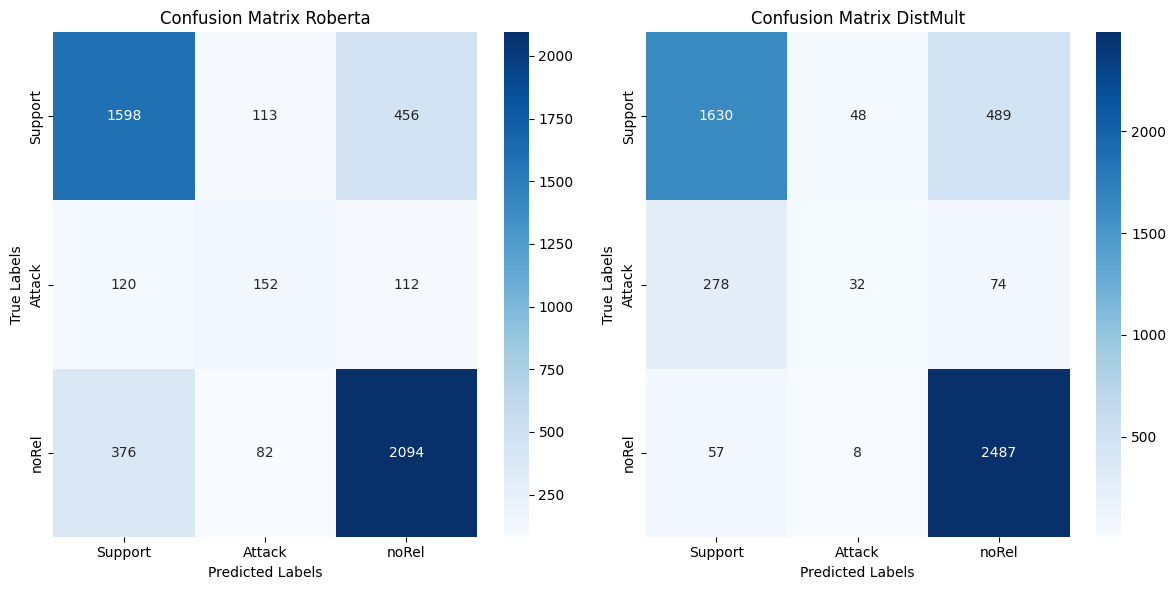

In [84]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(roberta_predictions['true'].map(lambda x: value_dict.get(x)), \
                             roberta_predictions['predicted'].map(lambda x: value_dict.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Roberta')

# Plotting Confusion Matrix for DistMult
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(distmult_predictions['true'].map(lambda x: value_dict.get(x)), \
                             distmult_predictions['predicted'].map(lambda x: value_dict.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix DistMult')

plt.tight_layout()
plt.show()

# **Stacked generalization**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
final_estimator = GradientBoostingRegressor(
    n_estimators=25, subsample=0.5, min_samples_leaf=25, max_features=1,
    random_state=42)
reg = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator)